v2:
- Drop train/val departures whose target lies outside of [1, 99] training percentile range
- Use last available month (Dec. 2025) as a validation set
- Arrival movements are not used
- Categorical features:
    - ADEP_mvt (apparently, taxi-out time depends on airport of departure)
    - ADEP_mvt == ADEP_flt (if not, it can affect taxi-out time)
    - RUNWAY_mvt (perhaps, taxi-out time can vary depending on runway)
    - STAND_mvt (stand as well)
    - WK_TBL_CAT_flt (heavier plane => probably bigger taxi-out time)
    - MARKET_SEGMENT_flt (perhaps, business or military aviation have less taxi-out time)
    - month/day/dow/hour/minute from SCHED_TIME_UTC_mvt (different seasons, less departures at night, etc.)
- Numerical features:
    - (f1) LOBT_flt - IOBT_flt (departure delays can affect taxi-out time)
    - (f2) ARVT_3_flt - ARVT_1_flt (arrival delays can indicate taxi-out deviation)
    - (f3) MVT_TIME_UTC_mvt - EOBT_1_flt (taxi-out time approximation)
    - (f4) MVT_TIME_UTC_mvt - AOBT_3_flt (taxi-out time approximation)
    - (f5) AOBT_3_flt - EOBT_1_flt (delays can indicate taxi-out deviation)
- Target: TAXITIME_SEC_mvt
- Model: CatBoost

In [ ]:
import sys

sys.path.append("../")

In [2]:
import os

import numpy as np
import optuna
import pandas as pd
from catboost import CatBoostRegressor

from src.features import v2_features

/opt/miniconda3/envs/ml/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Read training data

In [ ]:
def read_train(data_dir: str) -> pd.DataFrame:
    filenames = [x for x in os.listdir(data_dir) if x.startswith("training")]
    dfs = []
    for filename in filenames:
        month = int(filename.split("_")[1].split("-")[1])
        df = pd.read_parquet(os.path.join(data_dir, filename))
        df["month"] = month
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

In [4]:
df = read_train(data_dir="../data")
df.shape

(4167797, 31)

### Drop arrivals

In [5]:
df = df[df["PHASE_mvt"] == "DEP"]
df.shape

(2085047, 31)

### Make features

In [6]:
cat_features = [
    'ADEP_eq_flag',
    'ADEP_mvt',
    'RUNWAY_mvt',
    'STAND_mvt',
    'WK_TBL_CAT_flt',
    'MARKET_SEGMENT_flt',
    'SCHED_TIME_month',
    'SCHED_TIME_day',
    'SCHED_TIME_dow',
    'SCHED_TIME_hour',
    'SCHED_TIME_minute',
]
num_features = [
    'f1',
    'f2',
    'f3',
    'f4',
    'f5'
]
features = cat_features + num_features
v2_features(df=df)
with pd.option_context('display.max_columns', None):
    display(df.head(n=10))

,MVT_ID_mvt,FLIGHT_ID_mvt,FLIGHT_mvt,FLIGHT_RULE_mvt,ADEP_mvt,ADES_mvt,PHASE_mvt,MVT_TIME_UTC_mvt,BLOCK_TIME_UTC_mvt,SCHED_TIME_UTC_mvt,AIRCRAFT_TYPE_mvt,RUNWAY_mvt,STAND_mvt,TAXITIME_SEC_mvt,LOBT_flt,CALLSIGN_flt,ADEP_flt,ADES_flt,ADES_FILED_flt,MARKET_SEGMENT_flt,IOBT_flt,FLIGHT_RULE_flt,FLIGHT_TYPE_flt,AIRCRAFT_TYPE_flt,WK_TBL_CAT_flt,AIRCRAFT_OPERATOR_flt,EOBT_1_flt,ARVT_1_flt,AOBT_3_flt,ARVT_3_flt,month,ADEP_eq_flag,SCHED_TIME_month,SCHED_TIME_day,SCHED_TIME_dow,SCHED_TIME_hour,SCHED_TIME_minute,f1,f2,f3,f4,f5
1,193645647.0,288487967.0,LH390,I,EDDF,ELLX,DEP,2025-08-01 04:59:04+00:00,2025-08-01 04:46:08+00:00,2025-08-01 04:50:00+00:00,CRJ9,18,V117,776.0,2025-08-01 04:50:00+00:00,DLH6JV,EDDF,ELLX,ELLX,Regional,2025-08-01 04:50:00+00:00,I,S,CRJ9,M,11dca3faf5500fdddbb17189b5d18bcdc763244fcc850c...,2025-08-01 04:50:00+00:00,2025-08-01 05:32:29+00:00,2025-08-01 04:44:00+00:00,2025-08-01 05:22:57+00:00,8,True,8,1,4,4,50,0.0,-572.0,544.0,904.0,-360.0
2,193645641.0,288487848.0,LH1004,I,EDDF,EBBR,DEP,2025-08-01 05:00:37+00:00,2025-08-01 04:46:59+00:00,2025-08-01 04:45:00+00:00,A320,18,A24,818.0,2025-08-01 04:45:00+00:00,DLH9KW,EDDF,EBBR,EBBR,Mainline,2025-08-01 04:45:00+00:00,I,S,A320,M,11dca3faf5500fdddbb17189b5d18bcdc763244fcc850c...,2025-08-01 04:45:00+00:00,2025-08-01 05:40:43+00:00,2025-08-01 04:47:00+00:00,2025-08-01 05:42:00+00:00,8,True,8,1,4,4,45,0.0,77.0,937.0,817.0,120.0
5,193645649.0,288488070.0,LH350,I,EDDF,EDDW,DEP,2025-08-01 05:03:24+00:00,2025-08-01 04:59:49+00:00,2025-08-01 04:55:00+00:00,CRJ9,18,V171B,215.0,2025-08-01 04:55:00+00:00,DLH9CJ,EDDF,EDDW,EDDW,Regional,2025-08-01 04:55:00+00:00,I,S,CRJ9,M,11dca3faf5500fdddbb17189b5d18bcdc763244fcc850c...,2025-08-01 04:55:00+00:00,2025-08-01 05:52:08+00:00,2025-08-01 04:55:00+00:00,2025-08-01 05:43:43+00:00,8,True,8,1,4,4,55,0.0,-505.0,504.0,504.0,0.0
7,193645646.0,288487933.0,DE4427,I,EDDF,EDDM,DEP,2025-08-01 05:04:25+00:00,2025-08-01 04:50:35+00:00,2025-08-01 04:50:00+00:00,A319,18,V267,830.0,2025-08-01 04:50:00+00:00,CFG8YN,EDDF,EDDM,EDDM,Lowcost,2025-08-01 04:50:00+00:00,I,S,A319,M,2cf658a7fffbe4bd9af09b8b0e3ded4a207f1321a90981...,2025-08-01 04:50:00+00:00,2025-08-01 05:34:27+00:00,2025-08-01 04:56:00+00:00,2025-08-01 05:41:40+00:00,8,True,8,1,4,4,50,0.0,433.0,865.0,505.0,360.0
8,193645643.0,288487783.0,DE4179,I,EDDF,EDDH,DEP,2025-08-01 05:04:50+00:00,2025-08-01 04:48:32+00:00,2025-08-01 04:45:00+00:00,A321,25C,A16,978.0,2025-08-01 04:45:00+00:00,CFG3VR,EDDF,EDDH,EDDH,Lowcost,2025-08-01 04:45:00+00:00,I,S,A321,M,2cf658a7fffbe4bd9af09b8b0e3ded4a207f1321a90981...,2025-08-01 04:45:00+00:00,2025-08-01 05:49:59+00:00,2025-08-01 04:52:00+00:00,2025-08-01 05:47:28+00:00,8,True,8,1,4,4,45,0.0,-151.0,1190.0,770.0,420.0
9,193645648.0,288487922.0,DE4409,I,EDDF,LKPR,DEP,2025-08-01 05:05:58+00:00,2025-08-01 04:57:51+00:00,2025-08-01 04:50:00+00:00,A21N,18,V160,487.0,2025-08-01 04:50:00+00:00,CFG7XR,EDDF,LKPR,LKPR,Lowcost,2025-08-01 04:50:00+00:00,I,S,A21N,M,2cf658a7fffbe4bd9af09b8b0e3ded4a207f1321a90981...,2025-08-01 04:50:00+00:00,2025-08-01 05:45:21+00:00,2025-08-01 04:56:00+00:00,2025-08-01 05:45:00+00:00,8,True,8,1,4,4,50,0.0,-21.0,958.0,598.0,360.0
12,193645644.0,288487995.0,DE4355,I,EDDF,LIMC,DEP,2025-08-01 05:07:15+00:00,2025-08-01 04:51:17+00:00,2025-08-01 04:50:00+00:00,A320,18,V114,958.0,2025-08-01 04:50:00+00:00,CFG6RM,EDDF,LIMC,LIMC,Lowcost,2025-08-01 04:50:00+00:00,I,S,A320,M,2cf658a7fffbe4bd9af09b8b0e3ded4a207f1321a90981...,2025-08-01 04:50:00+00:00,2025-08-01 06:04:05+00:00,2025-08-01 04:50:00+00:00,2025-08-01 06:00:27+00:00,8,True,8,1,4,4,50,0.0,-218.0,1035.0,1035.0,0.0
17,193645654.0,288488259.0,LH924,I,EDDF,EGLL,DEP,2025-08-01 05:11:48+00:00,2025-08-01 05:01:34+00:00,2025-08-01 05:00:00+00:00,A20N,25C,B22,614.0,2025-08-01 05:00:00+00:00,DLH3ET,EDDF,EGLL,EGLL,Mainline,2025-08-01 05:00:00+00:00,I,S,A20N,M,11dca3faf5500fdddbb17189b5d18bcdc763244fcc850c...,2025-08-01 04:59:00+00:00,2025-08-01 06:13:26+00:00,2025-08-01 04:58:00+00:00,2025-08-01 06:21:00+00:00,8,True,

In [7]:
target = "TAXITIME_SEC_mvt"

### Convert NaN values in string categorical features to "NAN"

In [8]:
cat_str_features = [
    'ADEP_mvt',
    'RUNWAY_mvt',
    'STAND_mvt',
    'WK_TBL_CAT_flt',
    'MARKET_SEGMENT_flt',
]
df[cat_str_features] = df[cat_str_features].fillna("NAN")
df[cat_features + num_features].isna().sum()

ADEP_eq_flag              0
ADEP_mvt                  0
RUNWAY_mvt                0
STAND_mvt                 0
WK_TBL_CAT_flt            0
MARKET_SEGMENT_flt        0
SCHED_TIME_month          0
SCHED_TIME_day            0
SCHED_TIME_dow            0
SCHED_TIME_hour           0
SCHED_TIME_minute         0
f1                    22470
f2                    22470
f3                    22470
f4                    22470
f5                    22470
dtype: int64

### Split to train/val

In [9]:
df_train = df[df["month"] != 12]
df_val = df[df["month"] == 12]
df_train.shape, df_val.shape

((1919370, 42), (165677, 42))

### Drop train/val departures by [1, 99] range

In [10]:
q_1 = df_train["TAXITIME_SEC_mvt"].quantile(0.01)
q_99 = df_train["TAXITIME_SEC_mvt"].quantile(0.99)
df_train = df_train[(df_train["TAXITIME_SEC_mvt"] >= q_1) & (df_train["TAXITIME_SEC_mvt"] <= q_99)]
df_val = df_val[(df_val["TAXITIME_SEC_mvt"] >= q_1) & (df_val["TAXITIME_SEC_mvt"] <= q_99)]
print(f"1st percentile: {q_1}, 99th percentile: {q_99}")
df_train.shape, df_val.shape

1st percentile: 291.0, 99th percentile: 2339.0


((1881066, 42), (162569, 42))

### Hyperparameters tuning

In [11]:
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 5, 50),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1e-1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "verbose": False,
    }

    model = CatBoostRegressor(
        **params,
        cat_features=cat_features
    )
    model.fit(
        X=df_train[features],
        y=df_train[target],
        eval_set=(df_val[features], df_val[target]),
        early_stopping_rounds=30,
    )
    train_preds = model.predict(df_train[features])
    train_rmse = ((train_preds - df_train[target]) ** 2).mean() ** 0.5
    val_preds = model.predict(df_val[features])
    val_rmse = ((val_preds - df_val[target]) ** 2).mean() ** 0.5
    print(f"Trial {trial.number}: train RMSE = {train_rmse}, val RMSE = {val_rmse}")

    return val_rmse


In [12]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)
study.best_params

[I 2026-10-07 02:55:32,566] A new study created in memory with name: no-name-1e3d25b4-2b12-43d2-a95f-048d2f7283fb
[I 2026-10-07 02:55:51,357] Trial 0 finished with value: 336.18531268230595 and parameters: {'iterations': 44, 'depth': 10, 'learning_rate': 0.0018667833761340418, 'l2_leaf_reg': 0.0016718086498396705, 'random_strength': 0.004603821409911151, 'bagging_temperature': 0.8980502238391002, 'border_count': 251}. Best is trial 0 with value: 336.18531268230595.


Trial 0: train RMSE = 332.531655105664, val RMSE = 336.18531268230595


[I 2026-10-07 02:56:04,198] Trial 1 finished with value: 293.391637484535 and parameters: {'iterations': 29, 'depth': 6, 'learning_rate': 0.01500341929076189, 'l2_leaf_reg': 0.0021633290876692185, 'random_strength': 0.005682971180137884, 'bagging_temperature': 0.45203657011597664, 'border_count': 133}. Best is trial 1 with value: 293.391637484535.


Trial 1: train RMSE = 290.08024017504505, val RMSE = 293.391637484535


[I 2026-10-07 02:56:15,188] Trial 2 finished with value: 289.96473798110236 and parameters: {'iterations': 20, 'depth': 6, 'learning_rate': 0.02382091812193576, 'l2_leaf_reg': 0.008184720971493966, 'random_strength': 1.8622148276689026, 'bagging_temperature': 0.4535461183108189, 'border_count': 195}. Best is trial 2 with value: 289.96473798110236.


...

[I 2026-10-07 03:07:13,402] Trial 48 finished with value: 223.36339779433752 and parameters: {'iterations': 50, 'depth': 4, 'learning_rate': 0.06558065763102472, 'l2_leaf_reg': 0.0018251711805994575, 'random_strength': 0.17869959339930186, 'bagging_temperature': 0.23183979988029513, 'border_count': 225}. Best is trial 47 with value: 217.92984384244667.


Trial 48: train RMSE = 221.60575282497092, val RMSE = 223.36339779433752


[I 2026-10-07 03:07:28,684] Trial 49 finished with value: 217.5807706303918 and parameters: {'iterations': 38, 'depth': 5, 'learning_rate': 0.09775273050507412, 'l2_leaf_reg': 0.0013269442819089825, 'random_strength': 0.13793485060175284, 'bagging_temperature': 0.20841944902244344, 'border_count': 253}. Best is trial 49 with value: 217.5807706303918.


Trial 49: train RMSE = 216.76021322193688, val RMSE = 217.5807706303918


{'iterations': 38,
 'depth': 5,
 'learning_rate': 0.09775273050507412,
 'l2_leaf_reg': 0.0013269442819089825,
 'random_strength': 0.13793485060175284,
 'bagging_temperature': 0.20841944902244344,
 'border_count': 253}

### Refit on full data

In [13]:
df = df[(df["TAXITIME_SEC_mvt"] >= q_1) & (df["TAXITIME_SEC_mvt"] <= q_99)]
submit_model = CatBoostRegressor(**study.best_params, cat_features=cat_features)
submit_model.fit(
    X=df[features],
    y=df[target],
    early_stopping_rounds=30,
)

0:	learn: 331.9494294	total: 264ms	remaining: 9.77s
1:	learn: 318.0375136	total: 463ms	remaining: 8.32s
2:	learn: 306.0236171	total: 658ms	remaining: 7.68s
3:	learn: 295.3021701	total: 836ms	remaining: 7.11s
4:	learn: 285.9996486	total: 1.04s	remaining: 6.87s
5:	learn: 277.8374704	total: 1.21s	remaining: 6.45s
6:	learn: 270.8036969	total: 1.37s	remaining: 6.08s
7:	learn: 264.7591695	total: 1.56s	remaining: 5.86s
8:	learn: 259.3174837	total: 1.73s	remaining: 5.56s
9:	learn: 254.6950140	total: 1.88s	remaining: 5.28s
10:	learn: 250.6866195	total: 2.05s	remaining: 5.03s
11:	learn: 247.1431722	total: 2.21s	remaining: 4.78s
12:	learn: 243.8965202	total: 2.38s	remaining: 4.57s
13:	learn: 241.1219630	total: 2.54s	remaining: 4.35s
14:	learn: 238.6064758	total: 2.7s	remaining: 4.14s
15:	learn: 236.5189623	total: 2.87s	remaining: 3.94s
16:	learn: 234.6388098	total: 3.03s	remaining: 3.75s
17:	learn: 232.9627040	total: 3.19s	remaining: 3.54s
18:	learn: 231.4468459	total: 3.35s	remaining: 3.35s
19:	

CatBoostRegressor(bagging_temperature=0.20841944902244344, border_count=253, cat_features=['ADEP_eq_flag', 'ADEP_mvt', 'RUNWAY_mvt', 'STAND_mvt', 'WK_TBL_CAT_flt', 'MARKET_SEGMENT_flt', 'SCHED_TIME_month', 'SCHED_TIME_day', 'SCHED_TIME_dow', 'SCHED_TIME_hour', 'SCHED_TIME_minute'], depth=5, iterations=38, l2_leaf_reg=0.0013269442819089825, learning_rate=0.09775273050507412, loss_function='RMSE', random_strength=0.13793485060175284)

### Features importances

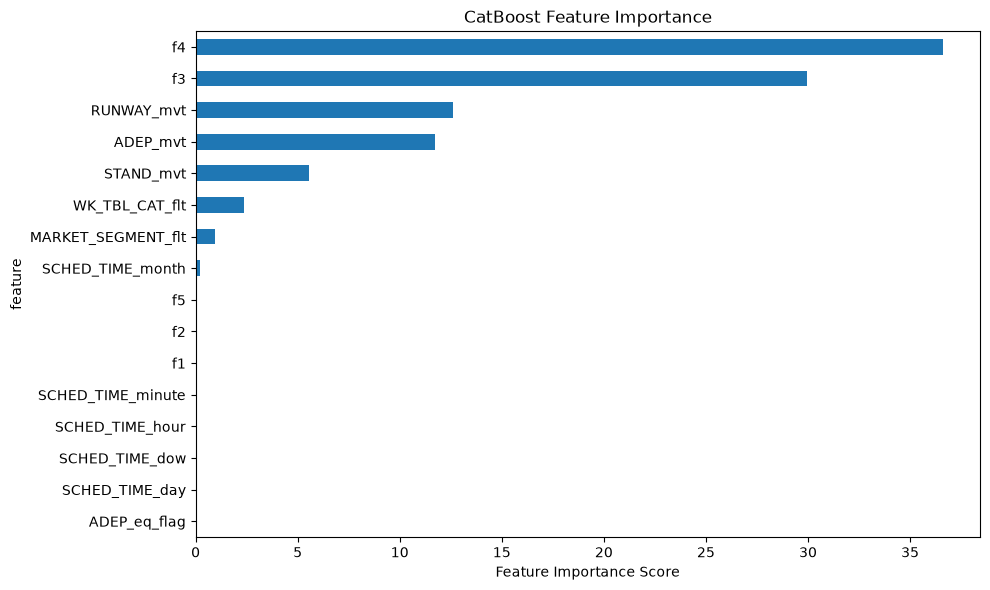

In [14]:
import matplotlib.pyplot as plt

importance_scores = submit_model.get_feature_importance()
feature_names = submit_model.feature_names_

df_importance = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": importance_scores
    }
).sort_values("importance", ascending=True)
df_importance.plot(x="feature", y="importance", kind="barh", figsize=(10, 6), legend=False)
plt.xlabel("Feature Importance Score")
plt.title("CatBoost Feature Importance")
plt.tight_layout()

### Make predictions for submit

In [15]:
df_test = pd.read_parquet("../data/ranking.parquet")
df_test = df_test[df_test["PHASE_mvt"] == "DEP"]
df_test.shape

(344841, 30)

In [16]:
v2_features(df=df_test)

In [17]:
df_test[cat_str_features] = df_test[cat_str_features].fillna("NAN")
df_test[features].isna().sum()

ADEP_eq_flag             0
ADEP_mvt                 0
RUNWAY_mvt               0
STAND_mvt                0
WK_TBL_CAT_flt           0
MARKET_SEGMENT_flt       0
SCHED_TIME_month         0
SCHED_TIME_day           0
SCHED_TIME_dow           0
SCHED_TIME_hour          0
SCHED_TIME_minute        0
f1                    5290
f2                    5290
f3                    5290
f4                    5290
f5                    5290
dtype: int64

In [18]:
test_preds = submit_model.predict(df_test[features])
test_preds[:5]

array([1129.35756362,  894.13809029,  667.91868078,  793.50328945,
        757.18854272])

In [19]:
submit = pd.DataFrame({
    "MVT_ID_mvt": df_test["MVT_ID_mvt"],
    "TAXITIME_SEC_mvt": test_preds
})
submit.to_parquet("incredible-rose_v2.parquet")
submit.shape

(344841, 2)